In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import gc

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

import torch
import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

"""FINAL WARNING: UserWarning silenced!"""
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()          # release cached blocks to the driver
    torch.cuda.ipc_collect()          # clean up inter-process caches
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.reset_accumulated_memory_stats()
    torch.cuda.synchronize()          # optional: ensure all work done

# Load genes

In [3]:
%%time
fpath="/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference/refdata-gex-GRCh38-2024-A_genes.csv.gz"
gdf = pd.read_csv(fpath, low_memory=False)
print(f"{gdf.shape=}")

# map from ensmbl IDs to gene names
id2gene = dict(zip(gdf['gene_id'].values, gdf['gene_name'].values))

# map from gene names to ensembl IDs
gene2id = dict(zip(gdf['gene_name'].values, gdf['gene_id'].values))

# label the pt genes
protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['gene_name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(3293161, 27)
N protein coding: protein_coding.shape=(19405,)
CPU times: user 15.3 s, sys: 3.57 s, total: 18.8 s
Wall time: 19 s


In [6]:
%%time
# Last run time 2min 5s
# --- paths ---------------------------------------------------------------
datas = {
    'HM05' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098741_HM05.csv.gz',
    'HM08' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098744_HM08.csv.gz',
    'HM10' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098746_HM10.csv.gz',
    'HM13' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098749_HM13.csv.gz',
    'HM21' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098751_HM21.csv.gz',
    'HM22' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098752_HM22.csv.gz',
}
# --- load each dataset in list -------------------------
adatas1 = []
for name, path in datas.items():
    print(f"Working on {name}...")
    a0 = pd.read_csv(path, index_col=0)
    a0 = a0.T
    a = an.AnnData(a0)
    a.obs['dataset'] = name
    adatas1.append(a)
    # a = sc.read_csv(path)
    # a = a.T
    # a.obs['dataset'] = name # track origin 
    # adatas1.append(a)
print("Data loaded.")

# --- concatenate -------------------------
mdata = an.concat(
    adatas1,
    axis=0,              # stack cells
    merge="unique",      # keep all obs columns; keep all genes, fill missing values with NaN
    label="dataset",     # new obs column with dataset name
    keys=list(datas),    # used by label and index_unique
    index_unique="-"     # make cell barcodes unique (adds "-dataset" suffix)
)

mdata.var['gene_id'] = mdata.var.index.map(gene2id) # add gene IDs
mask = mdata.var['gene_id'].notna() # remove NaN gene IDs
mdata = mdata[:, mask].copy()
mdata.var['gene_name'] = mdata.var_names # save gene names as column
mdata.var_names = mdata.var['gene_id'].values # set gene ID as index
mdata.obs['group'] = 'myofiber_data' # add group identifier

mdata

Working on HM05...
Working on HM08...
Working on HM10...
Working on HM13...
Working on HM21...
Working on HM22...
Data loaded.
CPU times: user 2min 17s, sys: 18.2 s, total: 2min 35s
Wall time: 2min 37s


AnnData object with n_obs × n_vars = 49645 × 13309
    obs: 'dataset', 'group'
    var: 'gene_id', 'gene_name'

In [7]:
### Checking if X is raw counts
print("adata.raw is None?", mdata.raw is None)

total_cells = mdata.n_obs

# Randomly sample 100 unique indices
sampled_indices = np.random.choice(total_cells, size=1000, replace=False)

tdata = mdata[sampled_indices, :].copy()
tdata

X = tdata.X.toarray() if hasattr(tdata.X, "toarray") else tdata.X
print(np.min(X), np.max(X), np.mean(X))

adata.raw is None? True
0 1647 0.13363175294913215


In [8]:
mdata.layers['raw_counts'] = mdata.X.copy()
mdata

AnnData object with n_obs × n_vars = 49645 × 13309
    obs: 'dataset', 'group'
    var: 'gene_id', 'gene_name'
    layers: 'raw_counts'

In [64]:
mdata.obs.head()

,dataset,group
AAACCTGAGTACGCCC-HM05,HM05,myofiber_data
AAACCTGAGTGGTCCC-HM05,HM05,myofiber_data
AAACCTGGTAAGAGAG-HM05,HM05,myofiber_data
AAACCTGGTAAGTGGC-HM05,HM05,myofiber_data
AAACCTGGTACCAGTT-HM05,HM05,myofiber_data


# Load Data

In [9]:
%%time
paths = {
    "our_data": "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad",
    "atlas":    "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/human_limb_scRNAseq.h5ad",
}

cell_types_keep = [
    "fibroblast of dermis","fibroblast",
    "muscle fibroblast","skeletal muscle myoblast",
    "myoblast","muscle cell",
]

adatas = []
t0 = time.perf_counter()
print("Starting load...")

for group, fpath in paths.items():
    t1 = time.perf_counter()
    print(f"\n[{group}] Loading: {fpath}")
    adata = sc.read_h5ad(fpath)
    print(f"[{group}] Loaded in {time.perf_counter()-t1:.2f}s "
          f"→ {adata.n_obs:,} cells × {adata.n_vars:,} vars")

    print(f"[{group}] .obs columns: {', '.join(adata.obs)}")

    if group == 'our_data':
        # set gene_id as var names
        adata.var_names = adata.var['gene_id'].values
        
    if group == "atlas":
        t2 = time.perf_counter()
        if "cell_type" in adata.obs:
            before = adata.n_obs
            mask = adata.obs["cell_type"].isin(cell_types_keep)
            kept = int(mask.sum())
            adata = adata[mask].copy()
            print(f"[{group}] Filtered by cell_type in {time.perf_counter()-t2:.2f}s "
                  f"→ kept {kept:,}/{before:,} cells ({kept/before:.1%})")
            
            t_gene = time.perf_counter()
            before_genes = adata.n_vars
            
            adata.var['gene_names'] = adata.var.index.map(id2gene)
            mask = adata.var['gene_names'].notna()
            kept_genes = int(mask.sum())
            adata = adata[:, mask].copy()
            # adata.var_names = adata.var['gene_names'].values
            
            print(f"[{group}] Gene map filter in {time.perf_counter()-t_gene:.2f}s "
                  f"→ kept {kept_genes:,}/{before_genes:,} genes ({kept_genes/before_genes:.1%}); "
                  f"dropped {before_genes - kept_genes:,}")
            
        else:
            print(f"[{group}] WARNING: 'cell_type' not found; skipping filter")

    # add grouping variable
    adata.obs["group"] = group

    # adata.var_names_make_unique()
    
    # set X to raw counts
    if 'raw_counts' in adata.layers.keys():
        # from our data
        adata.layers["raw_counts"] = adata.layers["raw_counts"].copy()
        adata.X = adata.layers['raw_counts'].copy()
        print(f"[{group}] Using raw counts from adata.layers['raw_counts']")
    elif adata.raw is not None:
        # For atlas (raw counts stored in adata.raw.X)
        print(f"[{group}] Extracting raw counts from adata.raw.X")
        
        # Map gene intersection to align dimensions
        shared_genes = adata.var_names.intersection(adata.raw.var_names)
        adata = adata[:, shared_genes].copy()
        
        X_raw = adata.raw[:, shared_genes].X
        X_raw = X_raw.toarray() if hasattr(X_raw, "toarray") else X_raw.copy()

        adata.layers["raw_counts"] = X_raw
        adata.X = X_raw
        print(f"[{group}] Using raw counts for {len(shared_genes):,} shared genes")
    else:
        print(f"[{group}] WARNING: No raw counts found; using adata.X as-is")


    # make var names unique
    adata.var_names_make_unique()

    print(f"[{group}] Final shape: {adata.n_obs:,} × {adata.n_vars:,}")
    adatas.append(adata)

    
# add myofiber data
print(f"\n[myofiber_data] Final shape: {mdata.n_obs:,} × {mdata.n_vars:,}")
adatas.append(mdata)
    
print("\nConcatenating...")
t3 = time.perf_counter()
adata = an.concat(adatas, join="outer", label="group", keys=['our_data', 'atlas', 'myofiber_data'])#keys=list(paths.keys()))
print(f"[concat] Done in {time.perf_counter()-t3:.2f}s")
print(f"[total] Finished in {time.perf_counter()-t0:.2f}s "
      f"→ {adata.n_obs:,} cells × {adata.n_vars:,} vars")

adata

Starting load...

[our_data] Loading: /nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad
[our_data] Loaded in 5.10s → 15,950 cells × 25,042 vars
[our_data] .obs columns: MYOD-fb_counts, PRRX1-fb_counts, PRRX1_MYOD-fb_counts, assigned_condition, total_fb_counts, condition_counts_rate, G1-fb_counts, G2M-fb_counts, S-fb_counts, dataset, total_reads, total_genes, pooled_condition, n_genes_by_counts, log1p_n_genes_by_counts, total_counts, log1p_total_counts, pct_counts_in_top_50_genes, pct_counts_in_top_100_genes, pct_counts_in_top_200_genes, pct_counts_in_top_500_genes, total_counts_mt, log1p_total_counts_mt, pct_counts_mt, total_counts_ribo, log1p_total_counts_ribo, pct_counts_ribo, outlier, mt_outlier, S_score, G2M_score, phase, leiden, cluster_str, leiden_split
[our_data] Using raw counts from adata.layers['raw_counts']
[our_data] Final shape: 15,950 × 25,042

[atlas] Loading: /nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxg

AnnData object with n_obs × n_vars = 105048 × 30437
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_

In [10]:
# Add 'myofiber' to cell type
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories('myofiber')
adata.obs.loc[adata.obs['group'] == 'myofiber_data', 'cell_type'] = 'myofiber'

In [11]:
# add gene names and gene id columns
adata.var['gene_name'] = adata.var.index.map(id2gene)
adata.var['gene_id'] = adata.var_names
print(adata.var['gene_name'].nunique())
print(adata.var['gene_id'].nunique())

# set gene name as the index and make them unique (there are ~13 duplicated gene names, but all IDs are unique)
adata.var_names = adata.var['gene_name'].values
adata.var_names_make_unique()

# make cell grouping
adata.obs['atlas_grouping'] = (
    adata.obs['cell_type'].combine_first(adata.obs['pooled_condition'])
)

print(adata.obs['atlas_grouping'].value_counts())
adata

30422
30437
atlas_grouping
myofiber                    49645
fibroblast of dermis        14105
skeletal muscle myoblast    10584
muscle fibroblast            7010
Control                      6960
fibroblast                   4650
siPRRX1/mmMYOD1              3451
siPRRX1                      3430
mmMYOD1                      2109
muscle cell                  1947
myoblast                     1157
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 105048 × 30437
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_

In [14]:
# dupes = adata.var['gene_name'][adata.var['gene_name'].duplicated(keep=False)]
# print(f"Number of duplicated gene names: {dupes.nunique()}")
# adata.var.loc[adata.var['gene_name'].isin(dupes)]

Number of duplicated gene names: 13


In [17]:
# total_cells = cdata.n_obs

# # Randomly sample 100 unique indices
# sampled_indices = np.random.choice(total_cells, size=1000, replace=False)

# tdata = cdata[sampled_indices, :].copy()
# tdata

# # X_raw = tdata.raw.X
# X_raw = tdata.layers['raw_counts'].copy()
# X_raw = X_raw.toarray() if hasattr(X_raw, "toarray") else X_raw

# print(X_raw.min(), X_raw.max(), X_raw.mean())
# print("Data type:", X_raw.dtype)

0.0 1464.0 0.32365918
Data type: float32


In [69]:
gene = 'MYOD1'
gene_idx = adata.var_names.get_loc(gene)

# tmp = adata[:, gene].copy()

tmp = adata.copy()

tmp.X = tmp.layers['raw_counts'].copy()

tmp_expr = tmp.X[:, gene_idx]

if hasattr(tmp_expr, 'toarray'):
    tmp_expr = tmp_expr.toarray().flatten()
else:
    tmp_expr = np.asarray(tmp_expr).flatten()


tmp_df = pd.DataFrame({'expression': tmp_expr, 'group': tmp.obs['atlas_grouping'].values})

# tmp_df.head()
tmp_df.groupby('group')['expression'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
Control,6960.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
fibroblast,4650.0,0.010323,0.113135,0.0,0.0,0.0,0.0,3.0
fibroblast of dermis,14105.0,0.010280,0.136687,0.0,0.0,0.0,0.0,8.0
mmMYOD1,2109.0,5.910384,4.176381,1.0,3.0,5.0,8.0,30.0
muscle cell,1947.0,4.106831,5.829620,0.0,0.0,2.0,6.0,50.0
muscle fibroblast,7010.0,0.009272,0.100219,0.0,0.0,0.0,0.0,2.0
myoblast,1157.0,4.264477,4.328536,0.0,1.0,3.0,6.0,29.0
myofiber,49645.0,0.079343,0.316485,0.0,0.0,0.0,0.0,7.0
siPRRX1,3430.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
### HERE 

# Re-score cell cycle

In [12]:
%%time
gene_path = '../../resources/regev_lab_cell_cycle_genes.txt'

regev_genes = [x.strip() for x in open(gene_path)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 7.59 s, sys: 5.85 s, total: 13.4 s
Wall time: 14.2 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,tissue_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,atlas_grouping
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,siPRRX1
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,siPRRX1


# Add gene-level mask

In [13]:
adata.var['protein_coding'] = adata.var.index.isin(protein_coding)
print(adata.var['protein_coding'].value_counts().to_string())

protein_coding
True     18047
False    12390


# Prep for Model

In [14]:
%%time
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(float)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")
print(f"{adata.X.dtype=}")

adata

adata.X.shape=(105048, 30437)
type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>
adata.X.dtype=dtype('float64')
CPU times: user 2.03 s, sys: 2.56 s, total: 4.59 s
Wall time: 4.9 s


AnnData object with n_obs × n_vars = 105048 × 30437
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_

# Preprocessing

In [15]:
%%time
print("Annotating mitochondrial, ribosomal, and hemoglobin genes...")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

print("Moving AnnData to CPU for QC metric calculation...")
rsc.get.anndata_to_CPU(adata)

print("Calculating QC metrics (log1p transformed)...")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

adata.var.head()

Annotating mitochondrial, ribosomal, and hemoglobin genes...
Moving AnnData to CPU for QC metric calculation...
Calculating QC metrics (log1p transformed)...
CPU times: user 8.52 s, sys: 3.36 s, total: 11.9 s
Wall time: 13.1 s


,gene_name,gene_id,protein_coding,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
TSPAN6,TSPAN6,ENSG00000000003,True,False,False,False,16710,0.223307,0.201558,84.092986,23458.0,10.063009
TNMD,TNMD,ENSG00000000005,True,False,False,False,4853,0.138632,0.129827,95.380207,14563.0,9.586308
DPM1,DPM1,ENSG00000000419,True,False,False,False,24137,0.322719,0.279690,77.022885,33901.0,10.431229
SCYL3,SCYL3,ENSG00000000457,True,False,False,False,6212,0.063066,0.061158,94.086513,6625.0,8.798757
C1orf112,C1orf112,ENSG00000000460,True,False,False,False,5431,0.063209,0.061292,94.829982,6640.0,8.801018


In [16]:
%%time

# print("Storing raw counts in .layers['raw_counts']...")
# adata.layers['raw_counts'] = adata.X.copy() ### They're already stored
adata.X = adata.layers['raw_counts'].copy()

print("Transferring AnnData back to GPU...")
rsc.get.anndata_to_GPU(adata)

print("Filtering cells with fewer than 500 counts...")
rsc.pp.filter_cells(adata, min_counts=500)

print("Filtering genes with fewer than 10 total counts...")
rsc.pp.filter_genes(adata, min_counts=10)

print("Filtering genes with zero counts across all cells...")
adata = adata[:, (adata.var['total_counts'] > 0)].copy()

min_n_genes = 1000
print(f"Subsetting cells with more than {min_n_genes} genes detected...")
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

print("Normalizing total counts to 1e4 per cell...")
rsc.pp.normalize_total(adata, target_sum=1e4)

print("Applying log1p transformation...")
rsc.pp.log1p(adata)

print("Computing highly variable genes...")
rsc.pp.highly_variable_genes(adata)

print("Storing log-normalized data in .layers['log_norm']...")
adata.layers['log_norm'] = adata.X.copy()

print("Preprocessing complete.")
adata

Transferring AnnData back to GPU...
Filtering cells with fewer than 500 counts...
filtered out 1481 cells that have less than 500 counts
Filtering genes with fewer than 10 total counts...
filtered out 2541 genes that are detected in less than 10 counts
Filtering genes with zero counts across all cells...
Subsetting cells with more than 1000 genes detected...
Normalizing total counts to 1e4 per cell...
Applying log1p transformation...
Computing highly variable genes...
Storing log-normalized data in .layers['log_norm']...
Preprocessing complete.
CPU times: user 15.9 s, sys: 18.4 s, total: 34.3 s
Wall time: 35.9 s


AnnData object with n_obs × n_vars = 70709 × 27896
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

In [17]:
adata.var['highly_variable'].value_counts()

highly_variable
False    21972
True      5924
Name: count, dtype: int64

In [18]:
adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# # disallow GO cell cycle genes
# fpath = "../../resources/human_cell_cycle_genes.csv"
# cdf = pd.read_csv(fpath)
# adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# # disallow Regev cell cycle genes
# fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
# genes = [x.strip() for x in open(fpath)]
# adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     17016
False    10880


# Batch key 

In [104]:
adata

AnnData object with n_obs × n_vars = 70709 × 27896
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

In [106]:
adata.obs['dataset'].value_counts()

dataset
Hybrid     8990
Control    6960
HM21       6898
HM10       3239
HM22       3213
HM13       2337
HM05       2184
HM08        268
Name: count, dtype: int64

In [ ]:
# hybrid, control

In [19]:
%%time
adata.obs['batch_key'] = np.where(
    adata.obs['dataset'].notna(), 
    adata.obs['dataset'], 
    adata.obs['assay'],
)

# collapse all batch_key values starting with 'HM' into 'GSE167186'
adata.obs['batch_key'] = np.where(
    adata.obs['batch_key'].str.startswith('HM', na=False),
    'GSE167186',
    adata.obs['batch_key']
)

print(adata.obs['batch_key'].value_counts(dropna=False).to_string())

batch_key
10x 3' v2    32537
GSE167186    18139
Hybrid        8990
Control       6960
10x 5' v1     4083
CPU times: user 16.8 ms, sys: 3.94 ms, total: 20.8 ms
Wall time: 27.6 ms


# SCVI

INFO: GPU available: True (cuda), used: True
2025-10-17 16:16:18 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2025-10-17 16:16:18 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-10-17 16:16:18 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2025-10-17 16:16:18 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: SLURM auto-requeueing enabled. Setting signal handlers.
2025-10-17 16:16:18 | [INFO] SLURM auto-requeueing enabled. Setting signal handlers.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
2025-10-17 16:24:33 | [INFO] `Trainer.fit` stopped: `max_epochs=200` reached.


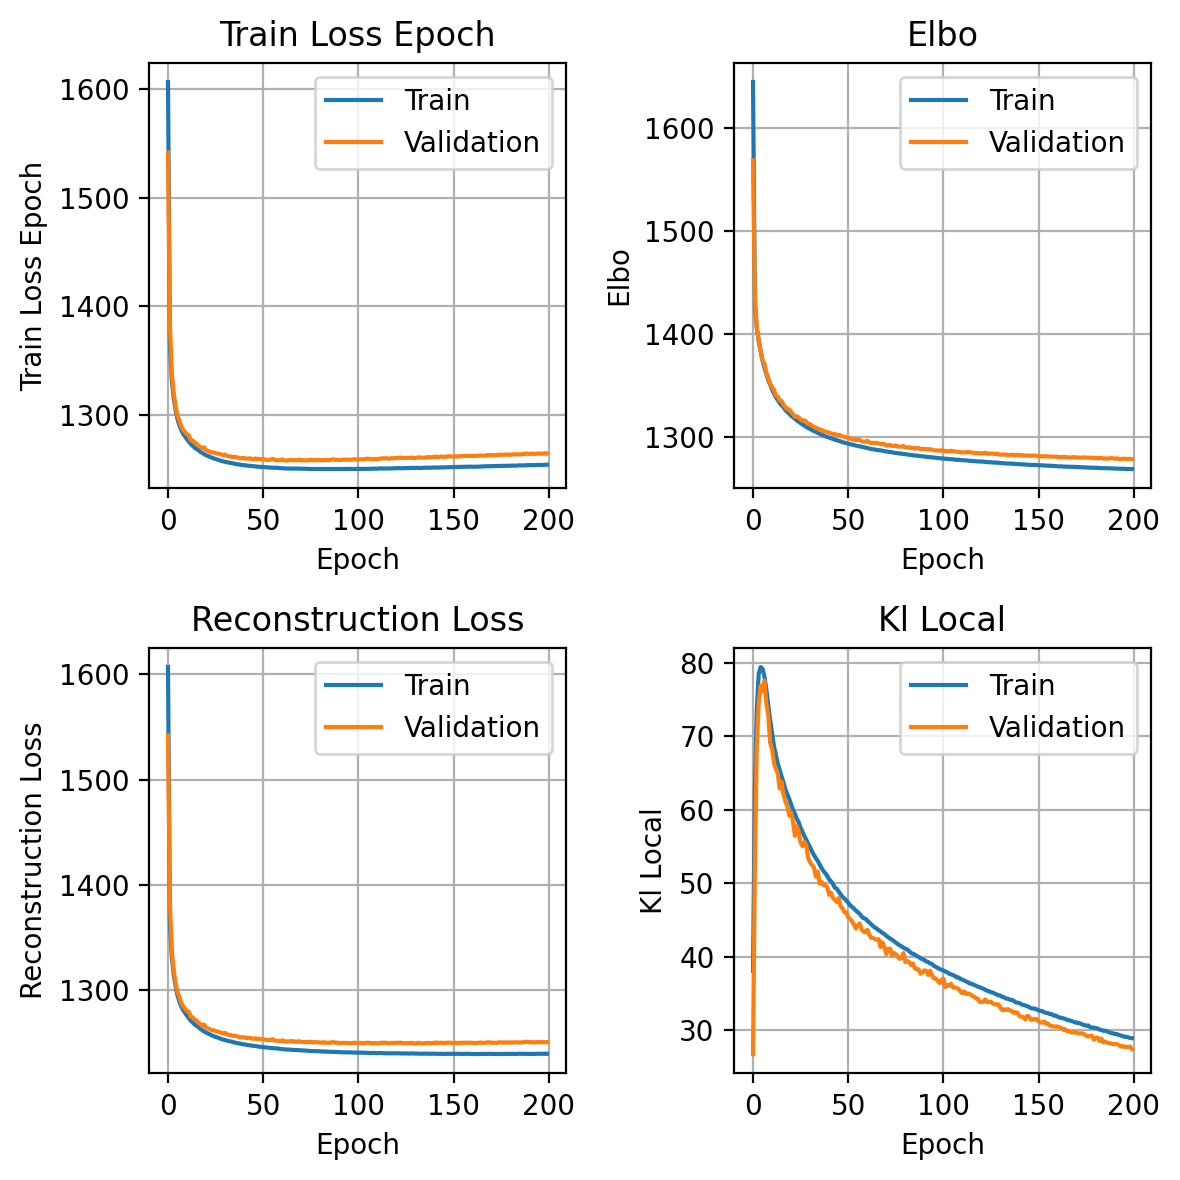

CPU times: user 8min 12s, sys: 19.2 s, total: 8min 31s
Wall time: 8min 41s


In [20]:
%%time
batch_key = "batch_key"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy() # retains protein-coding, removes mito and ribo genes
bdata.X = bdata.layers['raw_counts'].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=3500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=200, # 200
    accelerator='gpu',
    early_stopping_patience=10, # 5
    early_stopping=True,
    batch_size=500,
    plan_kwargs={"lr": 1e-3},
)

# clear cache once finished
torch.cuda.empty_cache()     

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Embedding

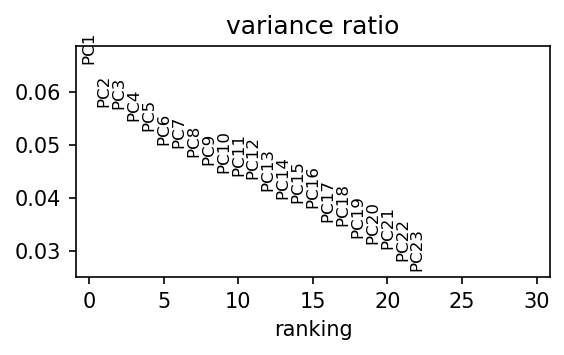

CPU times: user 1.67 s, sys: 83.9 ms, total: 1.75 s
Wall time: 1.95 s


In [21]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

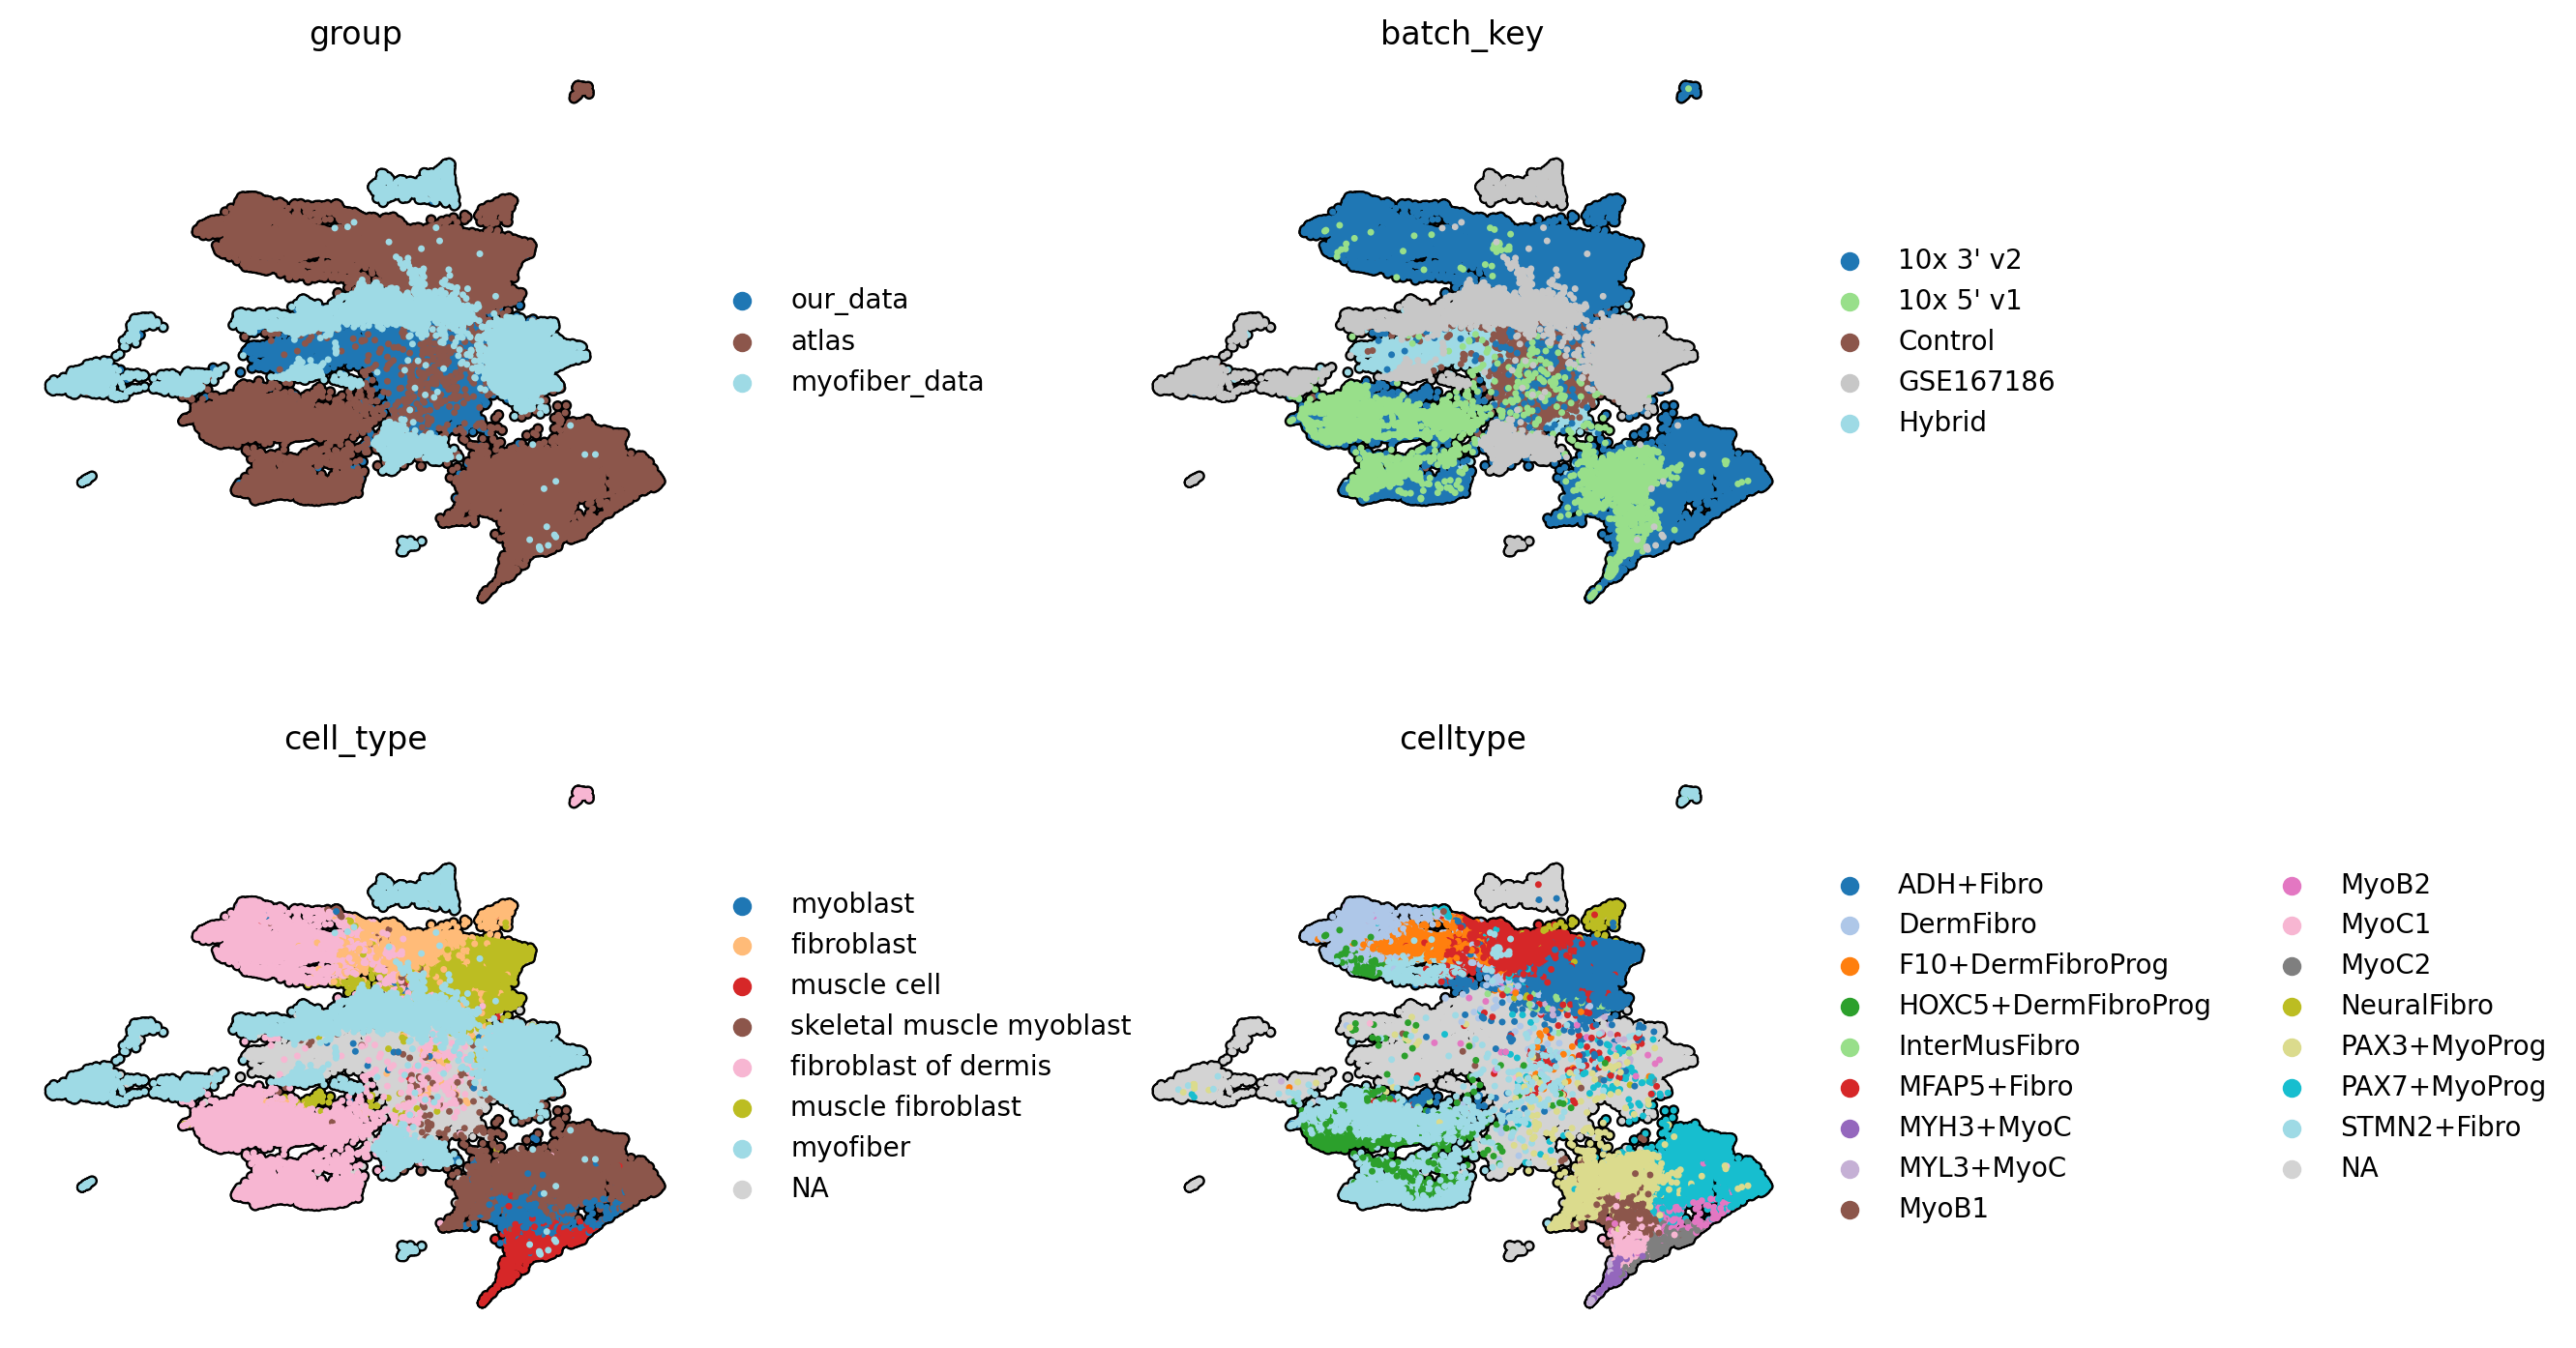

CPU times: user 7.37 s, sys: 178 ms, total: 7.54 s
Wall time: 7.68 s


In [24]:
%%time
n_neighbors = 15 # 100
n_pcs = 25
min_dist = 0.25
resolution = 0.75 

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

rsc.tl.umap(embed, min_dist=min_dist)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed,
    color=['group', 'batch_key', 'cell_type', 'celltype'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

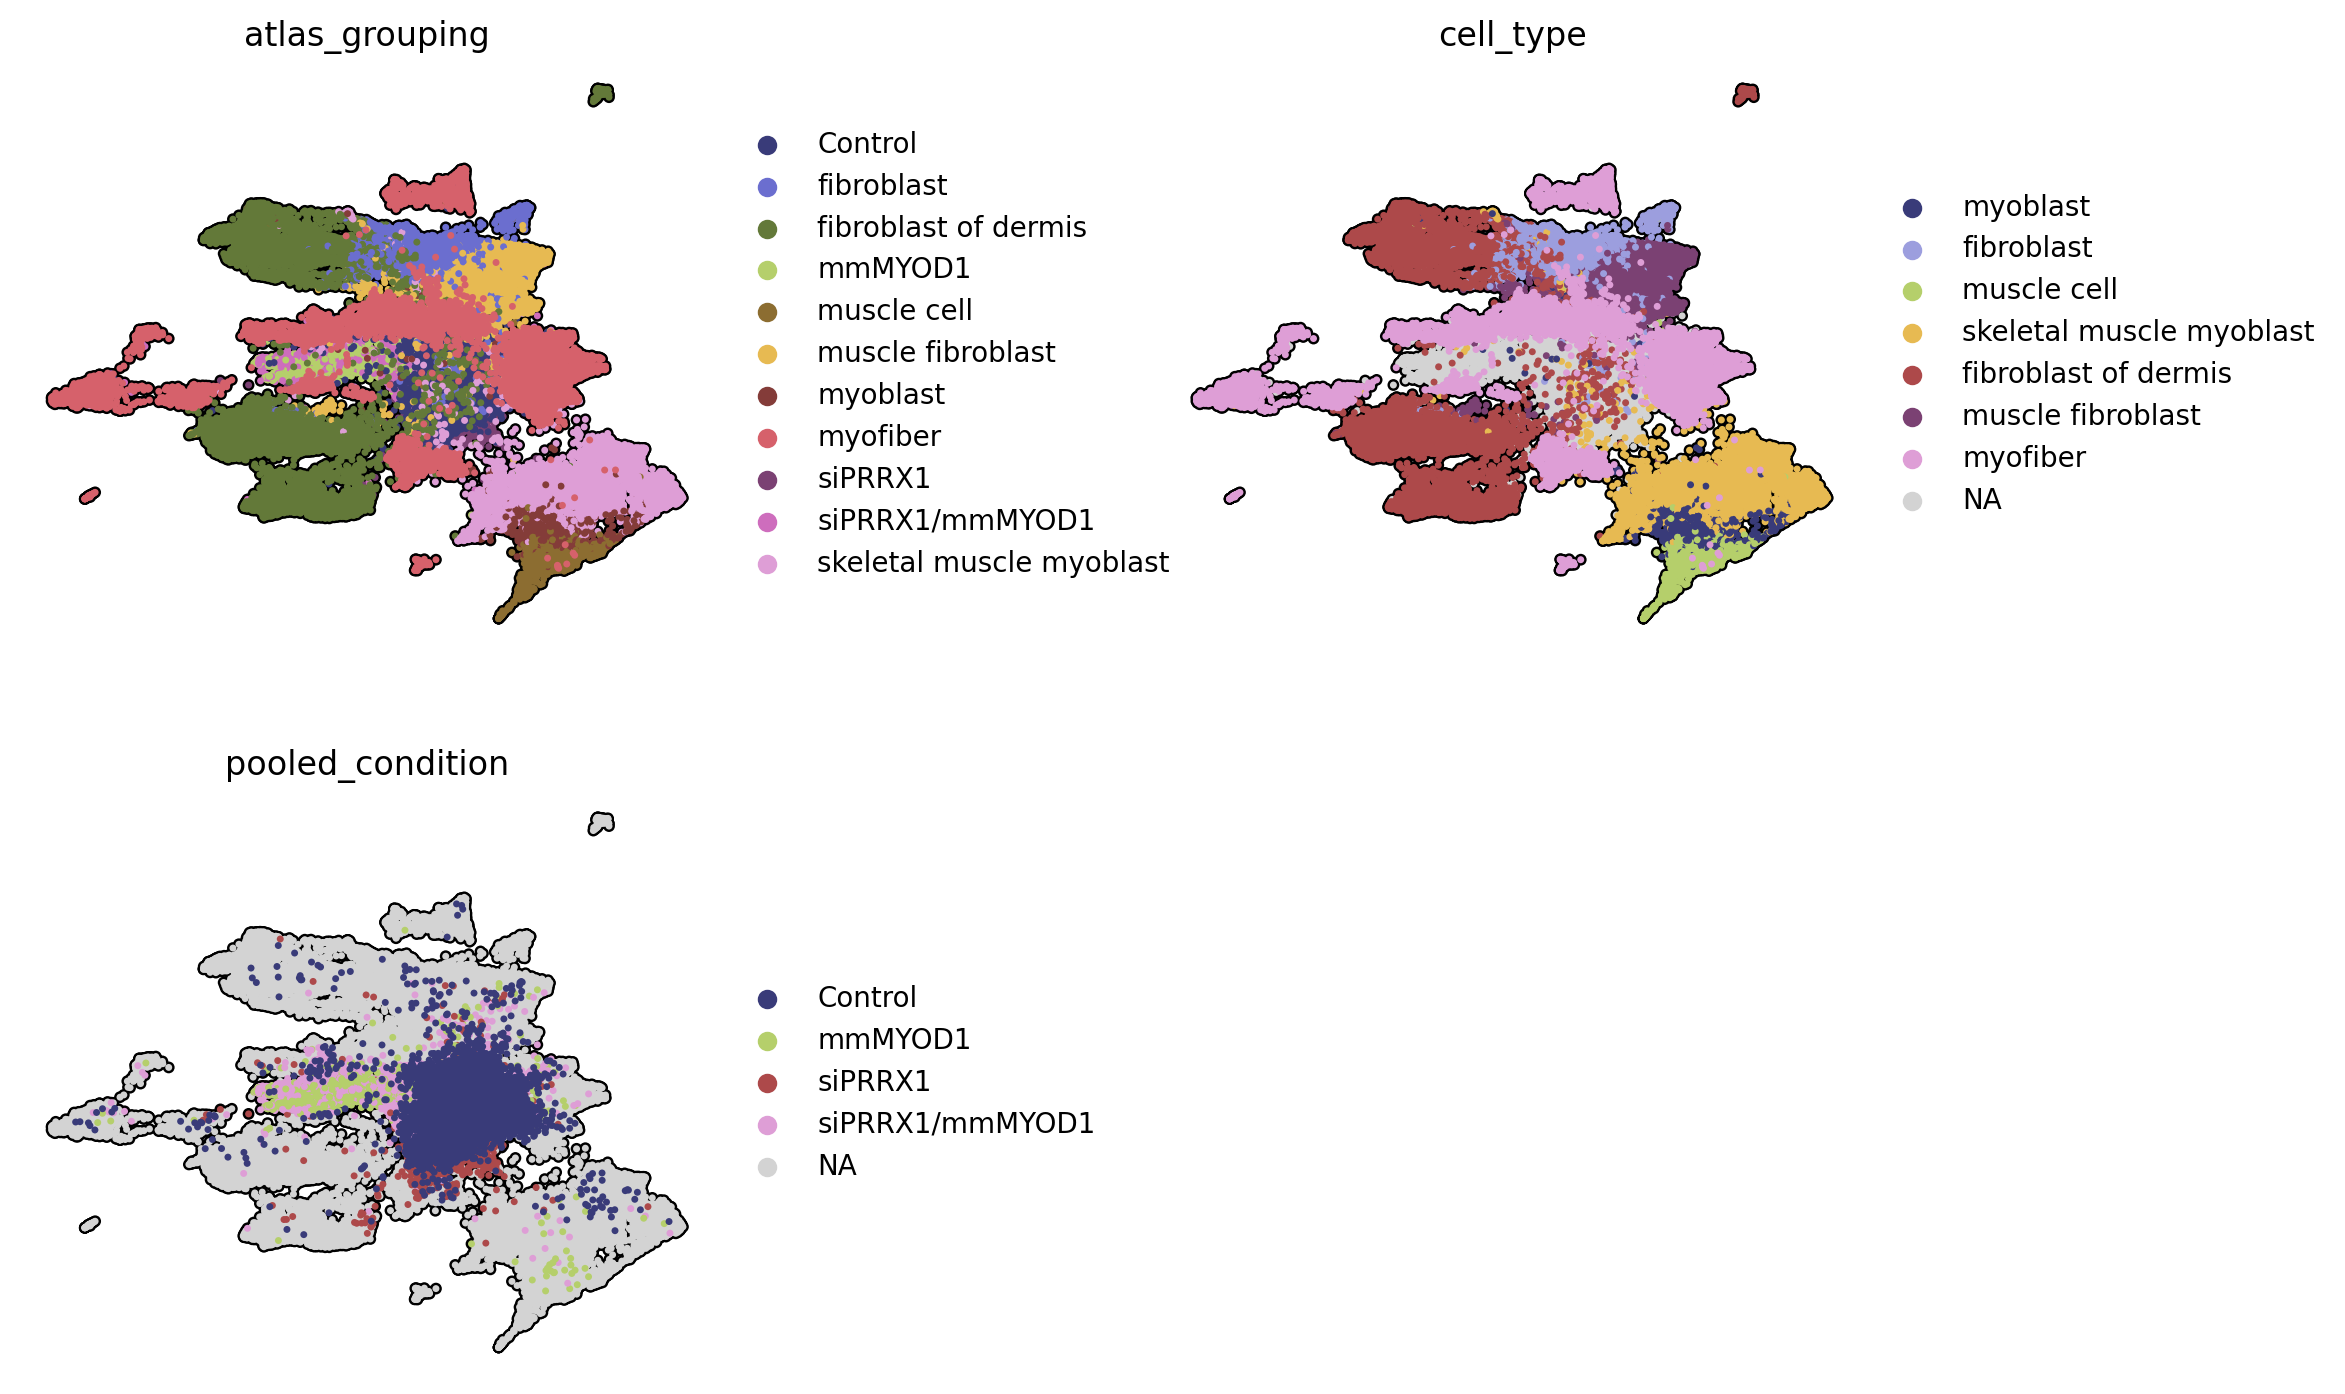

In [25]:
sc.pl.umap(
    embed,
    color=['atlas_grouping', 'cell_type', 'pooled_condition'],
    palette='tab20b',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [29]:
cols = ['region', 'adj_stage', 'adj_sample', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id',
        'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'suspension_type', 'tissue_type', 
        'cell_type', 'assay', 'disease', 'sex', 'tissue', 'development_stage']

embed.obs[cols].tail()

,region,adj_stage,adj_sample,celltype,assay_ontology_term_id,cell_type_ontology_term_id,development_stage_ontology_term_id,donor_id,is_primary_data,suspension_type,tissue_type,cell_type,assay,disease,sex,tissue,development_stage
TTTGCGCCACGGTGTC-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,PAX3+MyoProg,EFO:0011025,CL:0000515,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,skeletal muscle myoblast,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGCGCTCGGCGCAT-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,HOXC5+DermFibroProg,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTAGTGGGTTG-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTCAAGTCTAC-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTGTCGTGGCT-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16


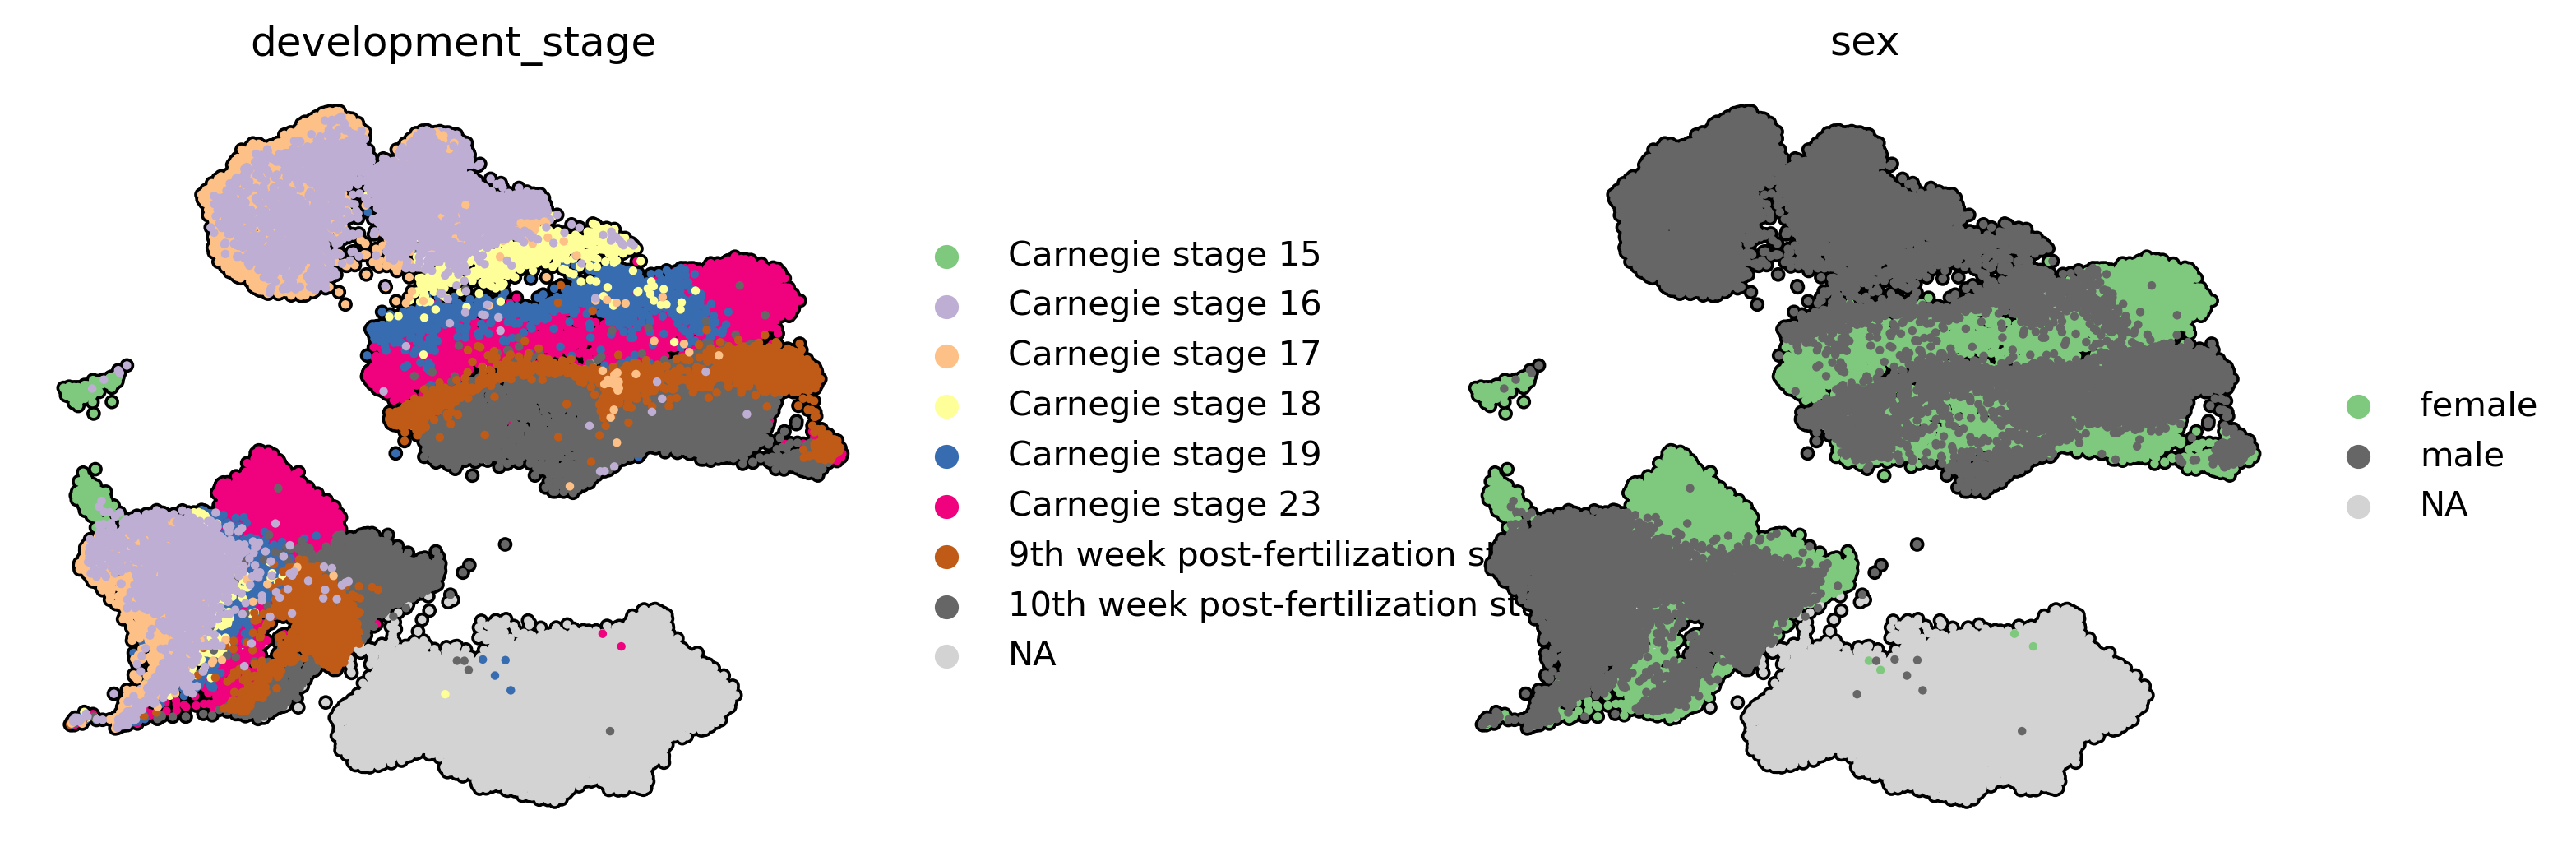

In [36]:
sc.pl.umap(
    embed,
    color=['development_stage', 'sex'],
    palette='Accent',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [37]:
embed.obs['donor_id'].value_counts()

donor_id
5478STDY7935101      5073
5478STDY7935102      3705
FCAImmP7536759       3445
FCAImmP7536758       3215
WSSS_THYst8796437    2020
5478STDY7980349      1938
5478STDY7980348      1798
5386STDY7557335      1675
5478STDY7652318      1464
5478STDY7717491      1273
5478STDY7717492      1204
5386STDY7557336      1132
5386STDY7557337      1112
WSSS_THYst9384954    1072
WSSS_THYst9384955    1019
WSSS_THYst9384957     922
WSSS_THYst8796438     911
WSSS_THYst8796441     878
WSSS_THYst9384958     588
5386STDY7537944       522
WSSS_THYst8796442     441
WSSS_THYst8796439     382
WSSS_THYst8796440     349
WSSS_THYst9384956     281
WSSS_THYst9384953     201
Name: count, dtype: int64

# Cluster

... storing 'cluster' as categorical



cluster
A1     12242
A9      7200
A13     5569
A15     5122
A14     4769
A6      4714
A11     4064
A12     3675
A17     3166
A2      2999
A7      2804
A4      2725
A10     2696
A8      2275
A16     1447
A3      1420
A5      1323
A18     1252
A19      848
A20      399



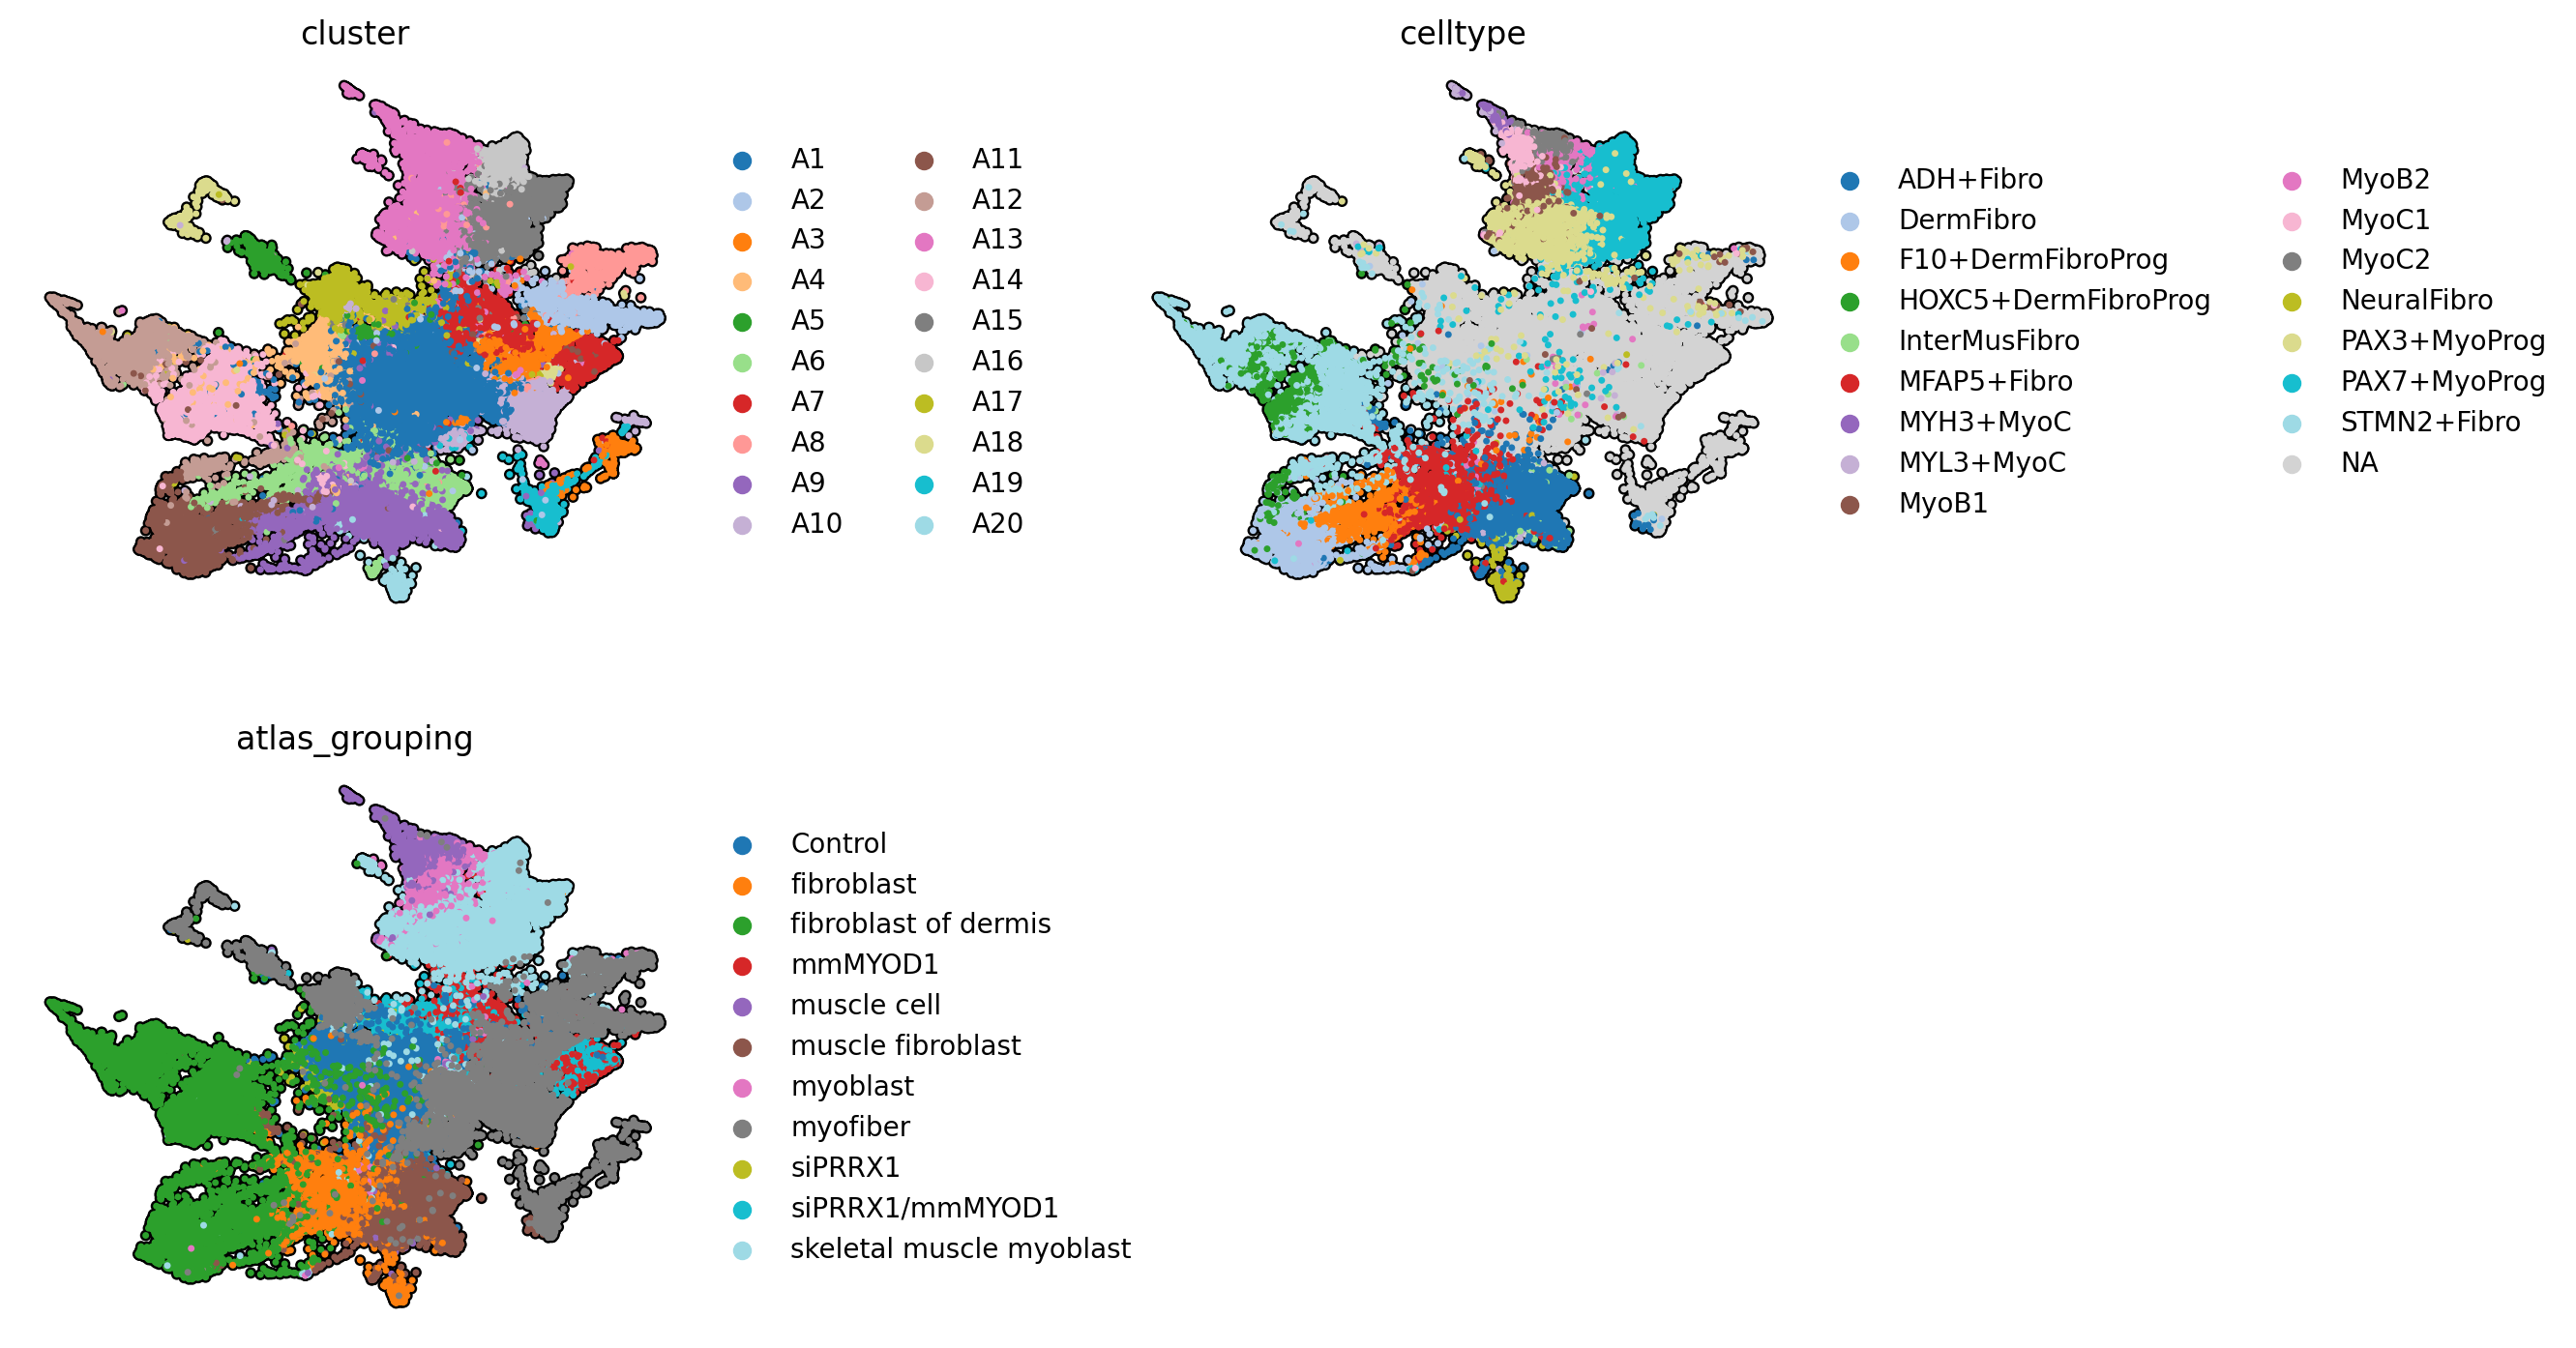

In [112]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

rsc.tl.leiden(embed, resolution=0.75)

embed.obs['cluster'] = embed.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
embed.obs['cluster'] = embed.obs['cluster'].astype('str')

print()
print(embed.obs['cluster'].value_counts().to_string())
print()

sc.pl.umap(
    embed,
    color=['cluster', 'celltype', 'atlas_grouping'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Add Coords

In [98]:
import cupyx

In [113]:
if isinstance(adata.layers['log_norm'], cupyx.scipy.sparse.csr_matrix):
    # Convert to SciPy CSR sparse
    adata.layers['log_norm'] = sp.csr_matrix(cp.asnumpy(adata.layers['log_norm'].toarray()))
    print("Converted log_norm layer to SciPy sparse matrix")

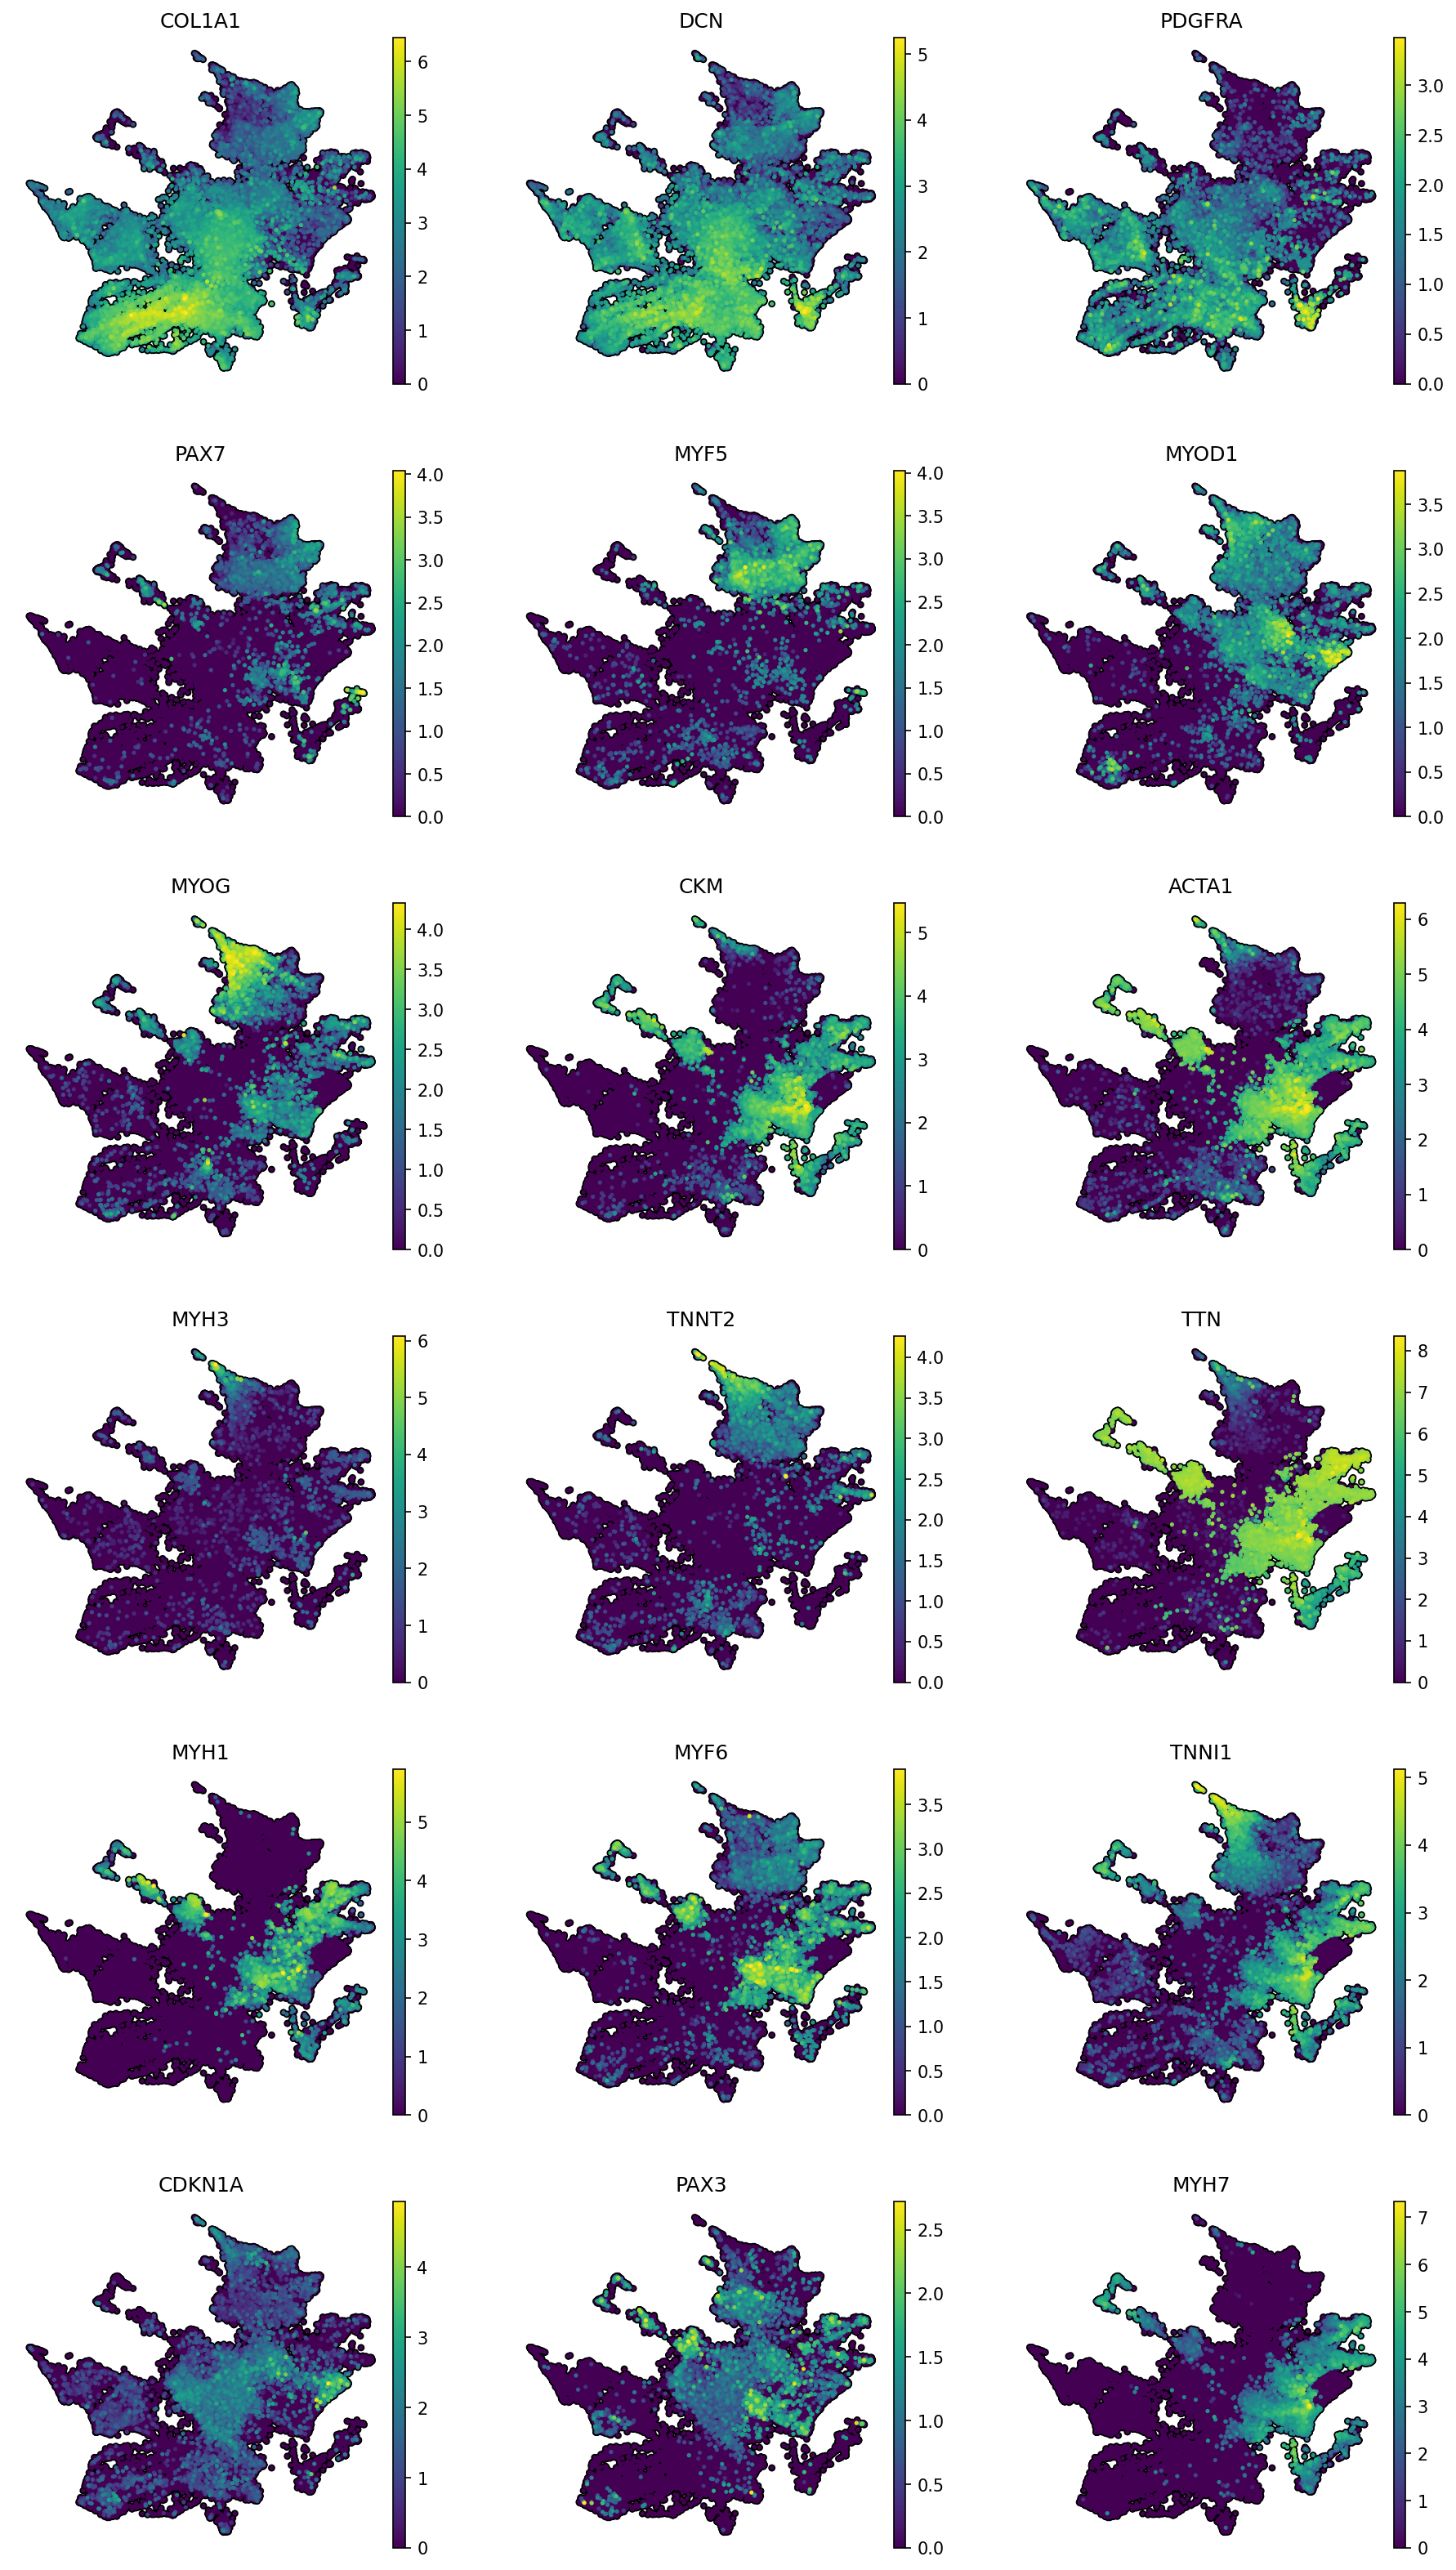

In [115]:
# rsc.get.anndata_to_CPU(adata)

adata.obsm['X_umap'] = embed.obsm['X_umap'].copy()

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

genes_to_plot = [
    # fibs
    'COL1A1', 'DCN', 'PDGFRA',
    # myoblasts
    'PAX7', 'MYF5', 'MYOD1',
    # myocytes
    'MYOG', 'CKM', 'ACTA1',
    # myotube
    'MYH3', 'TNNT2', 'TTN',
    # myofiber
    'MYH1', 'MYF6', 'TNNI1', 
    
    'CDKN1A', 'PAX3', 'MYH7',
]


sc.pl.umap(
    adata,
    color=genes_to_plot,
    # color=['MYOD1', 'MYOG', 'PAX3', 'MEF2C', 'COL1A1', 'DCN'],
    palette='tab20',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    # wspace=0.5,
)

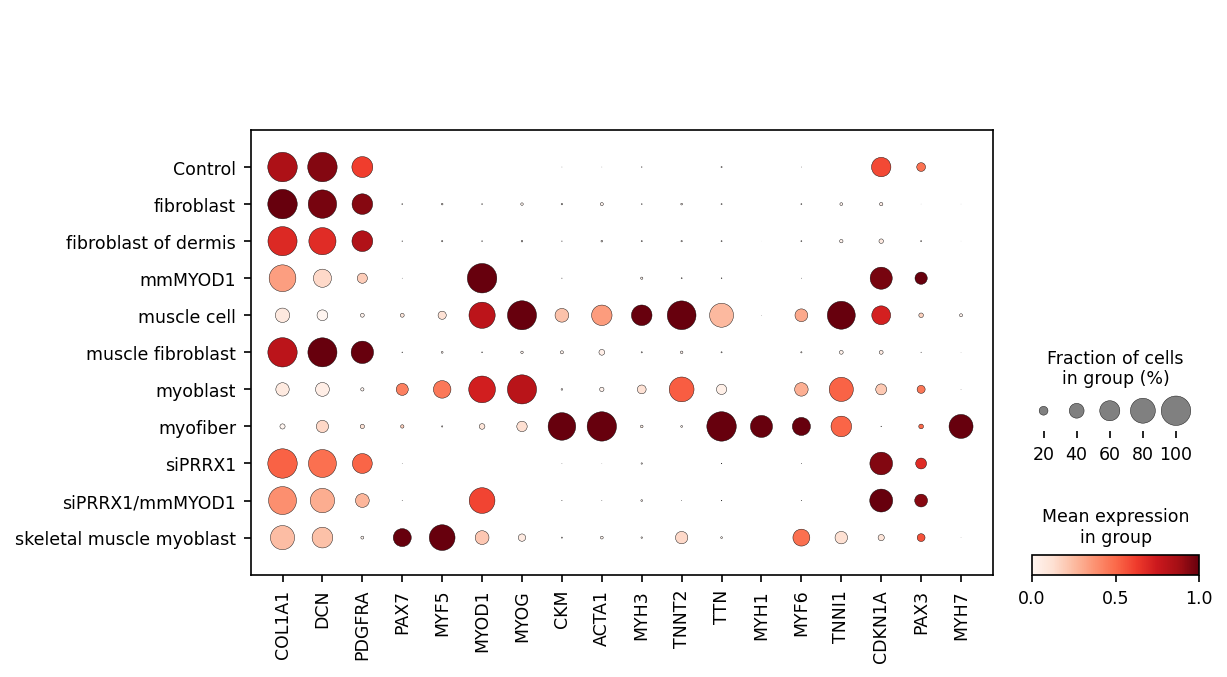

In [117]:
sc.pl.dotplot(
    adata,
    var_names=genes_to_plot,
    layer='log_norm',
    groupby='atlas_grouping',
    dendrogram=False,
    standard_scale='var',
)

# Add SCVI expression

In [101]:
df = model.get_normalized_expression()
adata.uns['scvi'] = df
adata

AnnData object with n_obs × n_vars = 70709 × 27896
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

In [102]:
[x for x in adata.uns['scvi'] if x.startswith('MYO')]

['MYOC',
 'MYOM2',
 'MYO16',
 'MYOM1',
 'MYOT',
 'MYOG',
 'MYO1B',
 'MYOD1',
 'MYO1G',
 'MYOCD',
 'MYO1F',
 'MYOM3',
 'MYO10',
 'MYO1A',
 'MYOZ2']

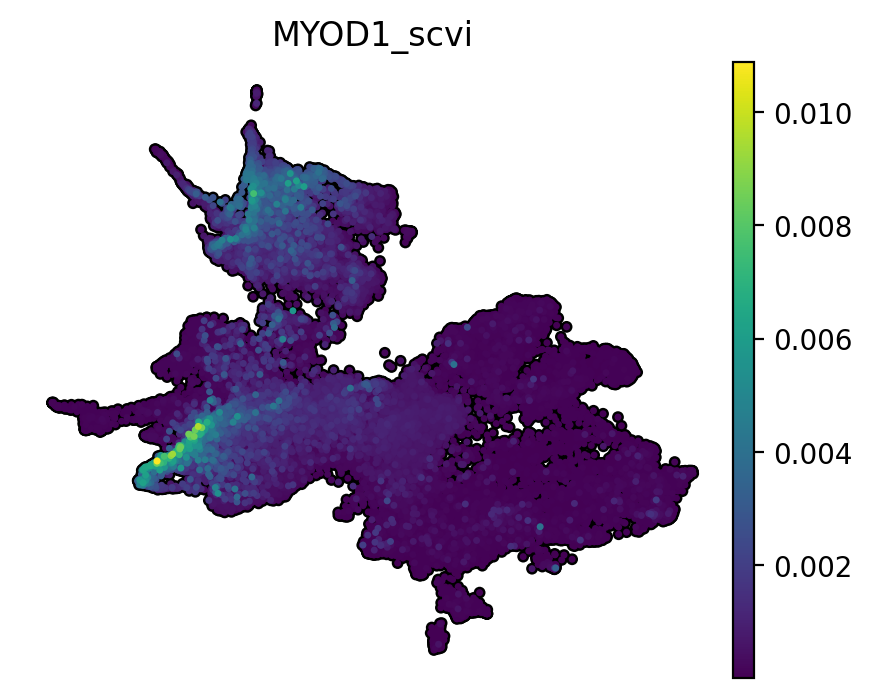

In [103]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4

color = 'MYOD1'
adata.obs[f"{color}_scvi"] = adata.uns['scvi'][color]

sc.pl.umap(
    adata,
    color=f"{color}_scvi",
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Write out

In [19]:
# %%time
# outpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference_atlas/hybrid_muscle_atlas.h5ad"
# adata.write(outpath)
# adata 